# MNIST Using CNN

- **Problem Type:** Classification
- **Evaluation Metric:** Accuracy
- **Model Used:** Convolutional Neural Network

## Loading Libraries

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import *
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, Dense, Input
from keras import optimizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings("ignore")

## Data Loading

In [2]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
X_train = X_train_full.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

X_train = np.expand_dims(X_train, -1)
X_test = np.expand_dims(X_test, -1)

y_train_cat = keras.utils.to_categorical(y_train_full, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

## EDA

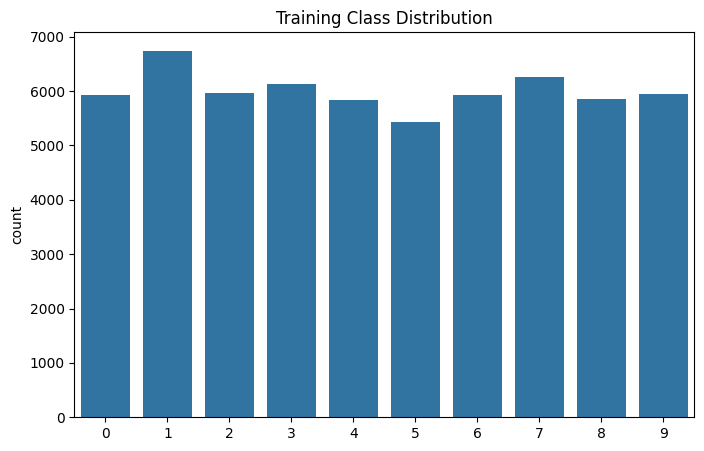

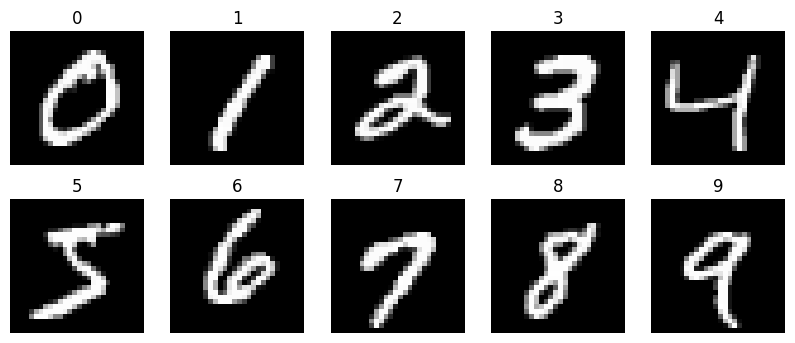

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(x=y_train_full)
plt.title("Training Class Distribution")
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img = X_train[y_train_full == i][0]
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(str(i))
    ax.axis("off")
plt.show()

## Traditional Machine Learning

Model Performance Comparison
------------------------------
              Model  Accuracy
      Decision Tree    0.3712
      Random Forest    0.2428
            XGBoost    0.1195
Logistic Regression    0.0892


Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.86      0.53      0.66       980
           1       0.54      0.93      0.68      1135
           2       0.27      0.34      0.30      1032
           3       0.04      0.00      0.01      1010
           4       0.44      0.70      0.54       982
           5       0.19      0.39      0.26       892
           6       0.00      0.00      0.00       958
           7       0.27      0.73      0.40      1028
           8       0.00      0.00      0.00       974
           9       0.00      0.00      0.00      1009

    accuracy                           0.37     10000
   macro avg       0.26      0.36      0.28     10000
weighted avg       0.27      0.37      0.29

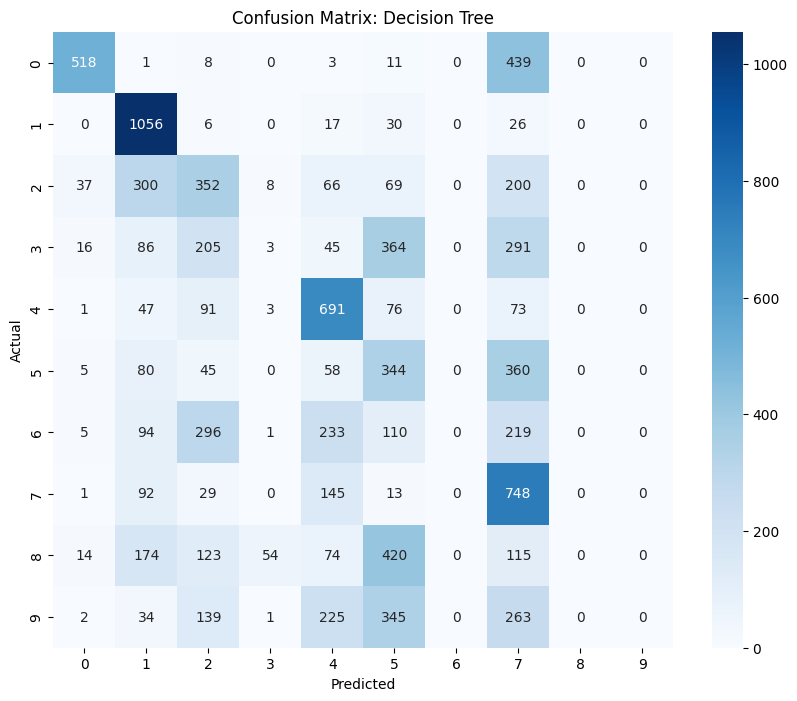

In [5]:
x_train_flat = X_train_full.reshape(-1, 28 * 28).astype("float32") / 255.0
x_test_flat = X_test.reshape(-1, 28 * 28).astype("float32") / 255.0

x_train_sub, _, y_train_sub, _ = train_test_split(
    x_train_flat, y_train_full, train_size=15000, random_state=42, stratify=y_train_full
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, n_jobs=-1, random_state=42
    ),
    "XGBoost": XGBClassifier(
        use_label_encoder=False, eval_metric="mlogloss", random_state=42, device="cuda"
    ),
}

results_list = []

for name, model in models.items():
    model.fit(x_train_sub, y_train_sub)
    y_pred = model.predict(x_test_flat)
    acc = accuracy_score(y_test, y_pred)
    results_list.append({"Model": name, "Accuracy": acc})

results_df = pd.DataFrame(results_list).sort_values(by="Accuracy", ascending=False)
print("Model Performance Comparison")
print("-" * 30)
print(results_df.to_string(index=False))
print("\n")

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

y_pred_best = best_model.predict(x_test_flat)

print(f"Classification Report for {best_model_name}:")
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

## Building the CNN

In [6]:
def build_model(opt_name, lr):
    keras.backend.clear_session()

    model = Sequential(
        [
            Input(shape=(28, 28, 1)),
            Conv2D(32, kernel_size=(3, 3), activation="relu"),
            MaxPooling2D(pool_size=(2, 2)),
            Conv2D(64, kernel_size=(3, 3), activation="relu"),
            MaxPooling2D(pool_size=(2, 2)),
            Flatten(),
            Dropout(0.5),
            Dense(10, activation="softmax"),
        ]
    )

    if opt_name == "Adam":
        opt = optimizers.Adam(learning_rate=lr)
    else:
        opt = optimizers.SGD(learning_rate=lr)

    model.compile(loss="categorical_crossentropy", optimizer=opt, metrics=["accuracy"])
    return model

## Finding the Best CNN Configuration

In [ ]:
# Parameters list
optimizers_list = ["Adam", "SGD"]
learning_rates = [0.01, 0.001]
batch_sizes = [64, 128]

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

cv_results_list = []
print("Starting 3-Fold CV Search for Classification...")
print("-" * 65)

for opt_name in optimizers_list:
    for lr in learning_rates:
        for batch in batch_sizes:
            fold_accuracies = []
            config_name = f"{opt_name}_LR{lr}_BS{batch}"

            start_time = time.perf_counter()

            for fold_idx, (train_idx, val_idx) in enumerate(
                skf.split(X_train, y_train_full)
            ):
                X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
                y_fold_train, y_fold_val = y_train_cat[train_idx], y_train_cat[val_idx]

                model = build_model(opt_name, lr)

                es = EarlyStopping(
                    monitor="val_accuracy", patience=3, restore_best_weights=True
                )
                rlr = ReduceLROnPlateau(
                    monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6
                )

                model.fit(
                    X_fold_train,
                    y_fold_train,
                    epochs=100,
                    batch_size=batch,
                    validation_data=(X_fold_val, y_fold_val),
                    callbacks=[es, rlr],
                    verbose=0,
                )

                loss, acc = model.evaluate(X_fold_val, y_fold_val, verbose=0)
                fold_accuracies.append(acc)

            mean_acc = np.mean(fold_accuracies)
            std_acc = np.std(fold_accuracies)

            end_time = time.perf_counter()
            elapsed_time = end_time - start_time

            print(
                f"Config: {config_name:25} | Mean Acc: {mean_acc:.4f} | StD: {std_acc:.4f} | Time Taken: {elapsed_time:.2f}s"
            )

            cv_results_list.append(
                {
                    "Optimizer": opt_name,
                    "LR": lr,
                    "BS": batch,
                    "Mean Accuracy": mean_acc,
                    "StD": std_acc,
                }
            )

CV_Results = pd.DataFrame(cv_results_list).sort_values(
    by="Mean Accuracy", ascending=False
)
print("\n" + "=" * 40)
print("TOP 5 ROBUST CONFIGURATIONS")
print("=" * 40)
display(CV_Results.head(5))

### Conclusion

From testing, the conclusion is that best parameters for CNN is as follows

- **Optimizer:** Adam
- **Learning Rate:** 0.01
- **Batch Size:** 128

**Resulting Accuracy:** 99.13%

now, train and evaluate the best CNN Configuration

In [ ]:
CV_Results.to_csv("mnist_cnn_cv_results.csv")

In [7]:
CV_Results = pd.read_csv("mnist_cnn_cv_results.csv")
CV_Results

,Unnamed: 0,Optimizer,LR,BS,Mean Accuracy,StD
0,1,Adam,0.010,128,0.991350,0.001250
1,2,Adam,0.001,64,0.990950,0.001205
2,0,Adam,0.010,64,0.990467,0.001236
3,3,Adam,0.001,128,0.990317,0.000792
4,4,SGD,0.010,64,0.982283,0.001450
5,5,SGD,0.010,128,0.978533,0.001897
6,6,SGD,0.001,64,0.969283,0.003065
7,7,SGD,0.001,128,0.959400,0.001899


## Training the Best CNN Configuration

In [8]:
# ---------------------------------------------------------
# 5. EXECUTE FINAL TRAINING
# ---------------------------------------------------------
best_opt = CV_Results.iloc[0]["Optimizer"]
best_lr = CV_Results.iloc[0]["LR"]
best_bs = CV_Results.iloc[0]["BS"]

print(f"\nTraining Final Model with {best_opt}, LR: {best_lr}, Batch: {best_bs}...")

keras.backend.clear_session()
final_model = build_model(best_opt, best_lr)

final_callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=7, min_lr=1e-7, verbose=1
    ),
]

final_history = final_model.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=150,
    batch_size=int(best_bs),
    callbacks=final_callbacks,
    verbose=1,
)


Training Final Model with Adam, LR: 0.01, Batch: 128...
Epoch 1/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9396 - loss: 0.1924 - val_accuracy: 0.9822 - val_loss: 0.0590 - learning_rate: 0.0100
Epoch 2/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9730 - loss: 0.0869 - val_accuracy: 0.9864 - val_loss: 0.0468 - learning_rate: 0.0100
Epoch 3/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9767 - loss: 0.0740 - val_accuracy: 0.9879 - val_loss: 0.0399 - learning_rate: 0.0100
Epoch 4/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9782 - loss: 0.0695 - val_accuracy: 0.9870 - val_loss: 0.0432 - learning_rate: 0.0100
Epoch 5/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9794 - loss: 0.0672 - val_accuracy: 0.9863 - val_loss: 0.0436 - learning_rate: 0.0100
Epoch 6/150
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9808 - loss: 0.0635 - val_accuracy: 0.9886 - val_loss: 0.0405 - learning_rate: 0.0100
Epoch 7/150
375/375 ━━━━━

## Evaluation

### Training & Validation Curve

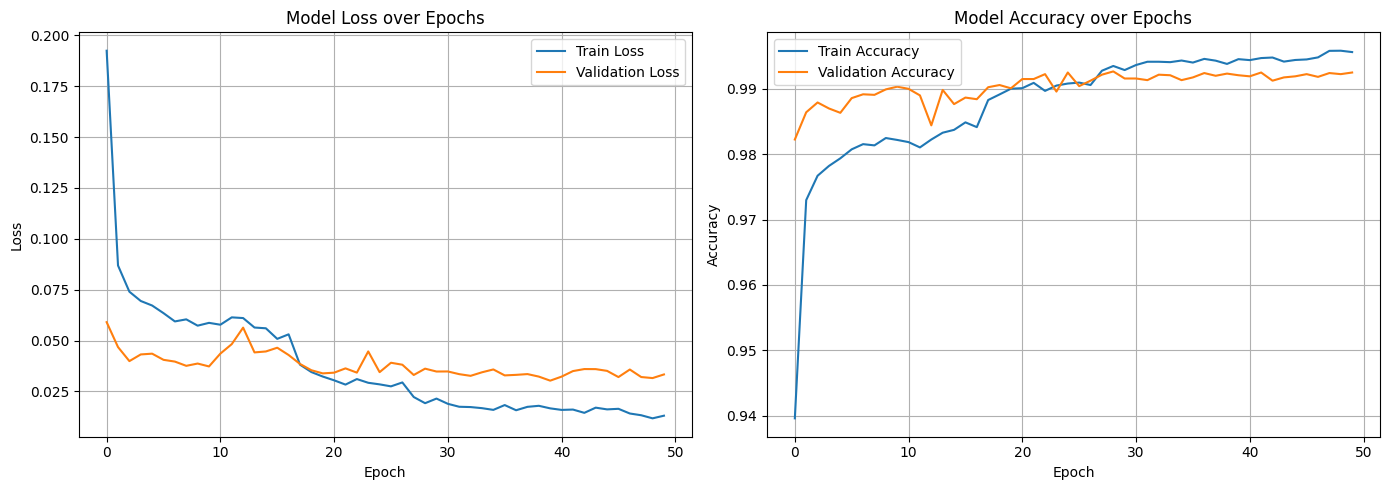

In [9]:
def plot_final_performance(history):
    plt.figure(figsize=(14, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title("Model Loss over Epochs")
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid(True)

    # Accuracy Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title("Model Accuracy over Epochs")
    plt.ylabel("Accuracy")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


plot_final_performance(final_history)

### Test Data Evaluation

In [10]:
score = final_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test loss: {score[0]:.4f}")
print(f"Test accuracy: {score[1]:.4f}")

Test loss: 0.0303
Test accuracy: 0.9918


### Classification Report

In [11]:
y_pred_prob = final_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



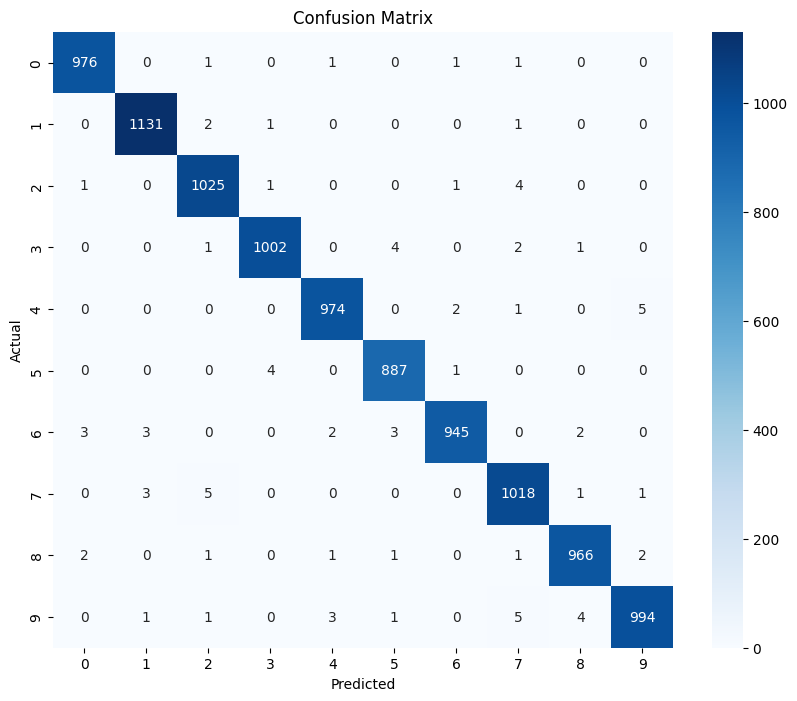

In [12]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title("Confusion Matrix")
plt.show()

## ML vs DL Comparison

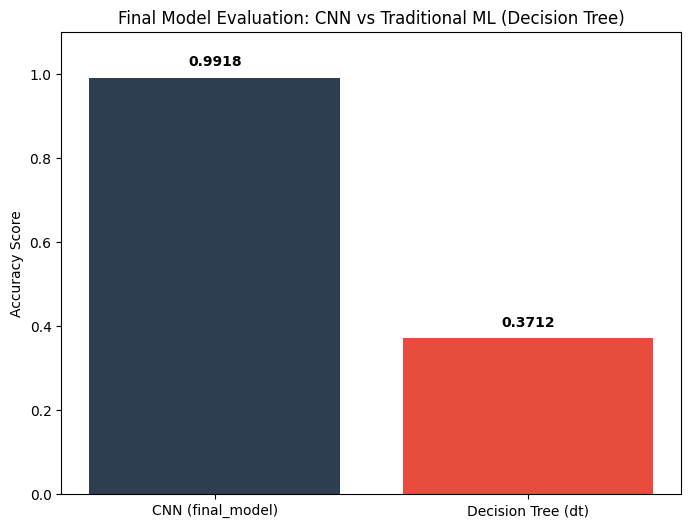

In [13]:
# Evaluate the CNN model on the reshaped image data
cnn_loss, cnn_accuracy = final_model.evaluate(X_test, y_test_cat, verbose=0)

# Evaluate the Decision Tree model on the flattened tabular data
dt_predictions = models["Decision Tree"].predict(x_test_flat)
dt_accuracy = accuracy_score(y_test, dt_predictions)

model_names = ["CNN (final_model)", "Decision Tree (dt)"]
accuracies = [cnn_accuracy, dt_accuracy]

plt.figure(figsize=(8, 6))
bars = plt.bar(model_names, accuracies, color=["#2c3e50", "#e74c3c"])

plt.ylim(0, 1.1)
plt.ylabel("Accuracy Score")
plt.title("Final Model Evaluation: CNN vs Traditional ML (Decision Tree)")

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.02,
        f"{yval:.4f}",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

plt.show()

## Conclusion

The Convolutional Neural Network (CNN) trained with the Adam optimizer was selected as the final model. The model achieved an exceptional validation accuracy of approximately 99%.

In [14]:
model_filename = "mnist_model.keras"
final_model.save(model_filename)

print(f"Success! Model and preprocessor saved as: {model_filename}")

Success! Model and preprocessor saved as: mnist_model.keras


## Synthetic Data Testing

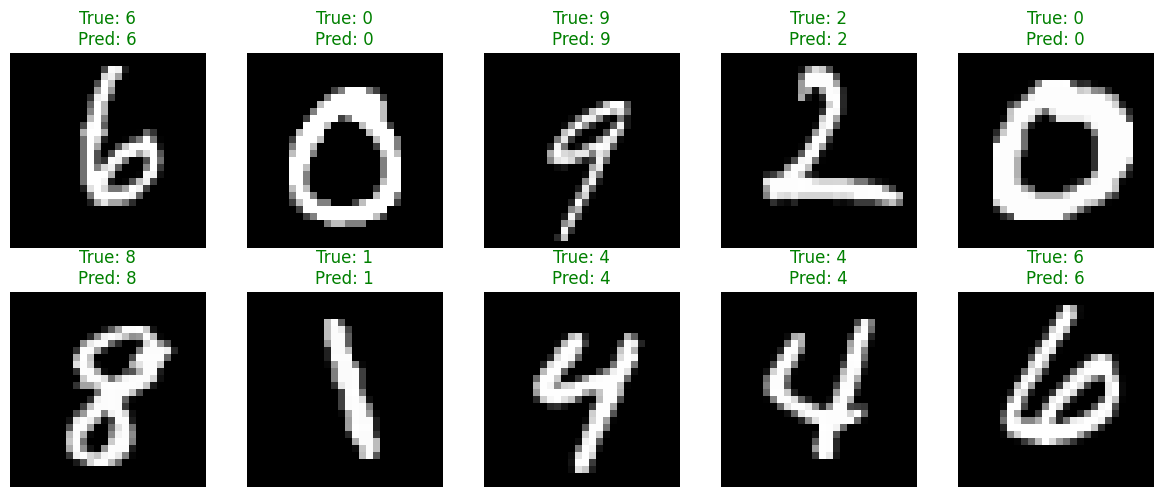

In [15]:
sample_indices = np.random.choice(len(X_test), 10, replace=False)
sample_images = X_test[sample_indices]
sample_labels_actual = y_test[sample_indices]

predictions_prob = final_model.predict(sample_images, verbose=0)
sample_labels_pred = np.argmax(predictions_prob, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].squeeze(), cmap="gray")
    actual = sample_labels_actual[i]
    pred = sample_labels_pred[i]
    title_color = "green" if actual == pred else "red"
    ax.set_title(f"True: {actual}\nPred: {pred}", color=title_color)
    ax.axis("off")
plt.tight_layout()
plt.show()